In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [2]:
df = pd.read_excel(r"C:\Users\USER\Downloads\AIr Quality Data - RDD 2026.xlsx", sheet_name="Sheet1")

# EXPLORING TEMTOP AIRING 2000 SERIES READINGS

In [3]:
df

,DATE,TIME,AREA,SAMPLING POINT,PM2.5(ug/m3),PM10(ug/m3),Humidity(%RH)
0,2026-03-04,10:39:00,PEEL BUILDING,1,15.600000,49.300000,41.30000
1,2026-03-04,10:40:00,PEEL BUILDING,1,15.600000,48.700000,42.00000
2,2026-03-04,10:41:00,PEEL BUILDING,1,16.200000,44.300000,43.30000
3,2026-03-04,10:42:00,PEEL BUILDING,1,16.800000,51.100000,43.80000
4,2026-03-04,10:43:00,PEEL BUILDING,1,16.700000,54.400000,44.20000
...,...,...,...,...,...,...,...
145,2026-03-04,12:41:00,Salford Crescent Railway Station,10,12.900000,49.600000,56.80000
146,2026-03-04,12:42:00,Salford Crescent Railway Station,10,12.900000,50.300000,54.00000
147,2026-03-04,12:43:00,Salford Crescent Railway Station,10,11.300000,43.900000,52.50000
148,2026-03-04,12:44:00,Salford Crescent Railway Station,10,10.200000,33.400000,50.70000


In [4]:
df.columns = df.columns.str.strip()

In [5]:
#Grouping data based on area and sampling point
cols = ["PM2.5(ug/m3)", "PM10(ug/m3)", "Humidity(%RH)"]

df_group = df.groupby(["AREA", "SAMPLING POINT"])[cols].mean().sort_values(by=cols).reset_index()

In [6]:
df_group

,AREA,SAMPLING POINT,PM2.5(ug/m3),PM10(ug/m3),Humidity(%RH)
0,Salford Crescent Railway Station,9,10.328352,56.696923,50.204835
1,Clifford Library/Front of Chapman Building,7,11.058681,30.320440,51.687692
2,Salford Crescent Railway Station,10,11.828571,43.767253,54.782637
3,PEEL PARK,5,12.233846,33.165934,52.102857
4,UNIVERSITY HOUSE,8,12.653333,34.633333,51.640000
5,PEEL BUILDING,2,14.840000,58.400000,51.280000
6,PEEL BUILDING,1,15.944615,47.451648,43.680000
7,PEEL PARK,6,17.809231,51.340879,55.932747
8,MAXWELL,3,20.285165,59.167582,40.626154
9,MAXWELL,4,22.973187,61.353333,47.997582


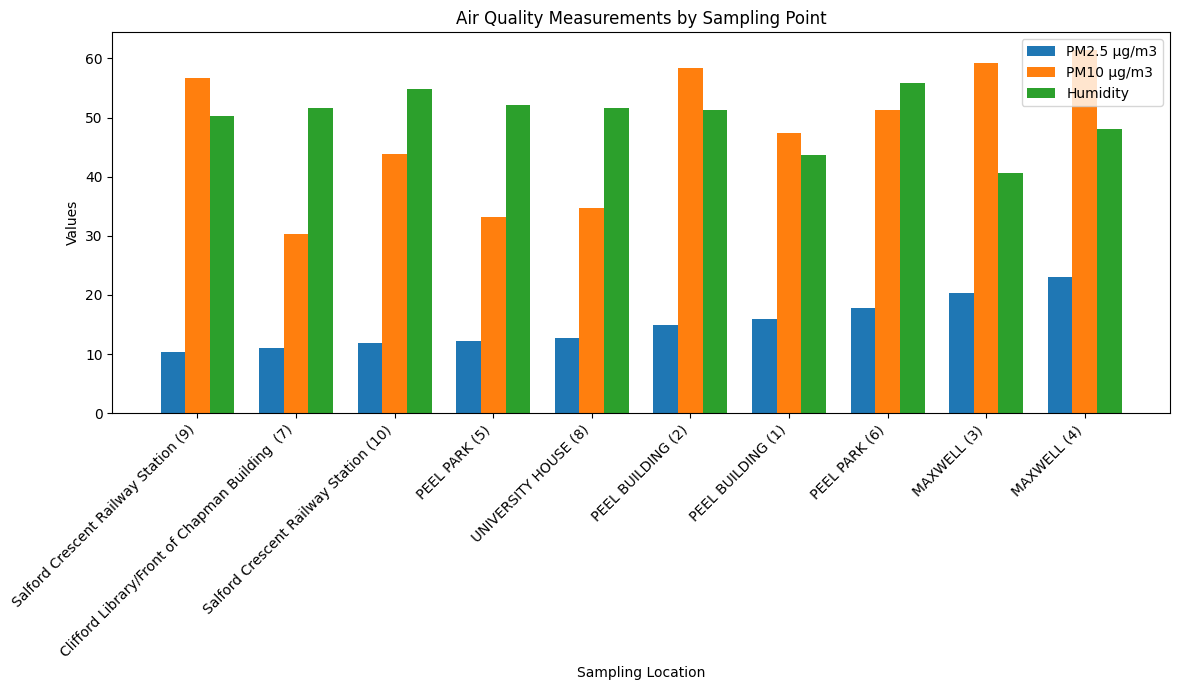

In [8]:
x = np.arange(len(df_group))  # one position per row
width = 0.25

plt.figure(figsize=(12,7))

plt.bar(x - width, df_group["PM2.5(ug/m3)"], width, label="PM2.5 µg/m3")
plt.bar(x, df_group["PM10(ug/m3)"], width, label="PM10 µg/m3")
plt.bar(x + width, df_group["Humidity(%RH)"], width, label="Humidity")

# Labels (combine AREA + Sampling Point for clarity)
df_group["labels"] = df_group["AREA"] + " (" + df_group["SAMPLING POINT"].astype(str) + ")"

plt.xticks(x, df_group["labels"], rotation=45, ha="right")

plt.xlabel("Sampling Location")
plt.ylabel("Values")
plt.title("Air Quality Measurements by Sampling Point")

plt.legend()
plt.tight_layout()
plt.savefig("All Air Qual.png")
plt.show()

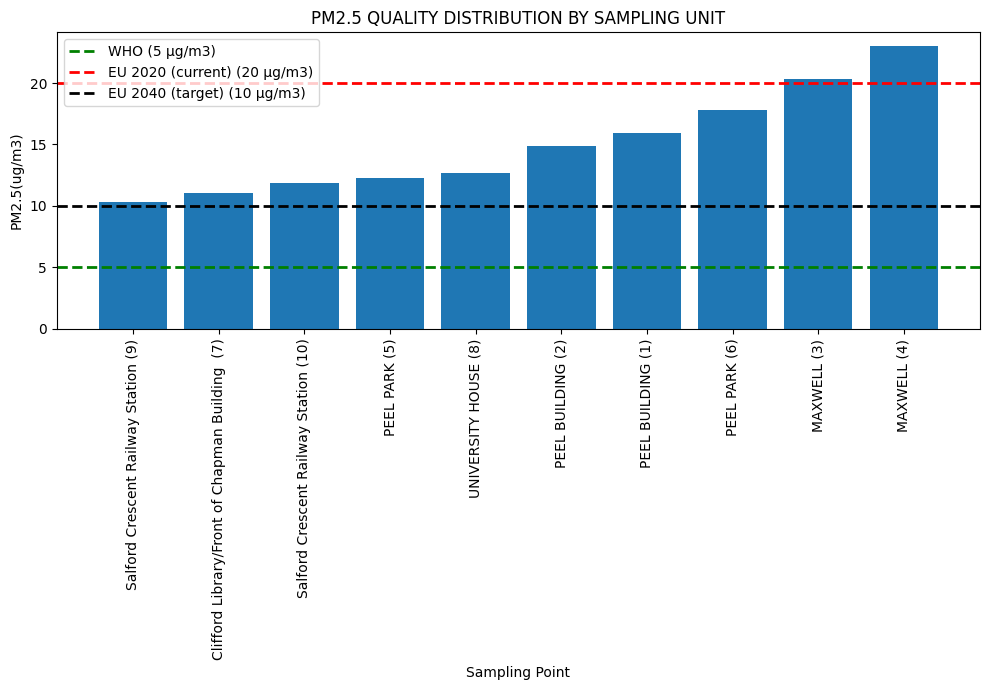

In [11]:
plt.figure(figsize=(10, 7))
plt.bar(df_group["labels"], df_group["PM2.5(ug/m3)"])

#Organisational Threshold
plt.axhline(y=5, color='green', linestyle='--', linewidth=2, label='WHO (5 µg/m3)')
plt.axhline(y=20, color='red', linestyle='--', linewidth=2, label='EU 2020 (current) (20 µg/m3)')
plt.axhline(y=10, color='black', linestyle='--', linewidth=2, label='EU 2040 (target) (10 µg/m3)')

plt.xlabel("Sampling Point")
plt.ylabel("PM2.5(ug/m3)")
plt.title("PM2.5 QUALITY DISTRIBUTION BY SAMPLING UNIT")
plt.legend()
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig("PM2.5 AIRING 2000.png")
plt.show()

In [13]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="PM10(ug/m3)",
    y="PM2.5(ug/m3)",
    hue=df_labels
)

plt.title("PM2.5 vs PM10 by Sampling Point")
plt.savefig("PM2.5 & PM10.png")
plt.show()

NameError: name 'df_labels' is not defined

<Figure size 1000x600 with 0 Axes>

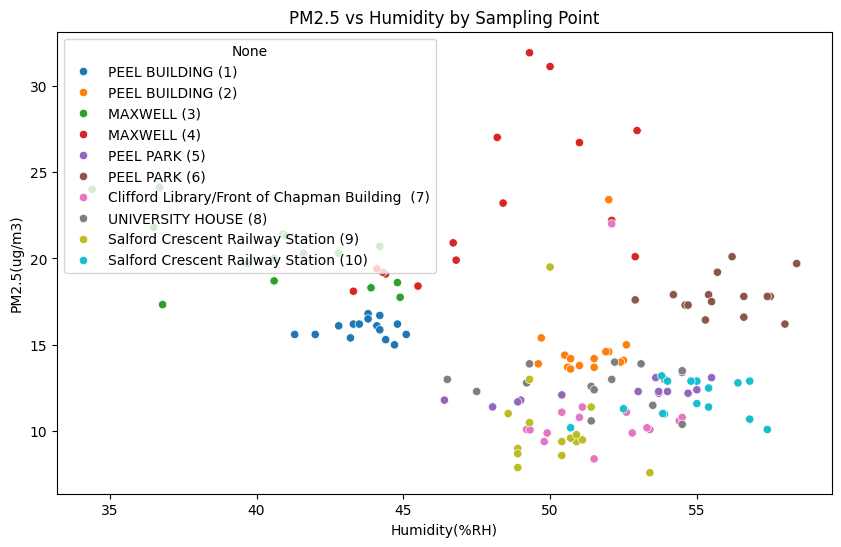

In [120]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="Humidity(%RH)",
    y="PM2.5(ug/m3)",
    hue=df_labels
)

plt.title("PM2.5 vs Humidity by Sampling Point")
plt.savefig("PM2.5 & Humidity.png")
plt.show()

In [93]:
df_group

,AREA,SAMPLING POINT,PM2.5(ug/m3),PM10(ug/m3),Humidity(%RH),labels
0,Salford Crescent Railway Station,9,10.328352,56.696923,50.204835,Salford Crescent Railway Station (9)
1,Clifford Library/Front of Chapman Building,7,11.058681,30.320440,51.687692,Clifford Library/Front of Chapman Building (7)
2,Salford Crescent Railway Station,10,11.828571,43.767253,54.782637,Salford Crescent Railway Station (10)
3,PEEL PARK,5,12.233846,33.165934,52.102857,PEEL PARK (5)
4,UNIVERSITY HOUSE,8,12.653333,34.633333,51.640000,UNIVERSITY HOUSE (8)
5,PEEL BUILDING,2,14.840000,58.400000,51.280000,PEEL BUILDING (2)
6,PEEL BUILDING,1,15.944615,47.451648,43.680000,PEEL BUILDING (1)
7,PEEL PARK,6,17.809231,51.340879,55.932747,PEEL PARK (6)
8,MAXWELL,3,20.285165,59.167582,40.626154,MAXWELL (3)
9,MAXWELL,4,22.973187,61.353333,47.997582,MAXWELL (4)


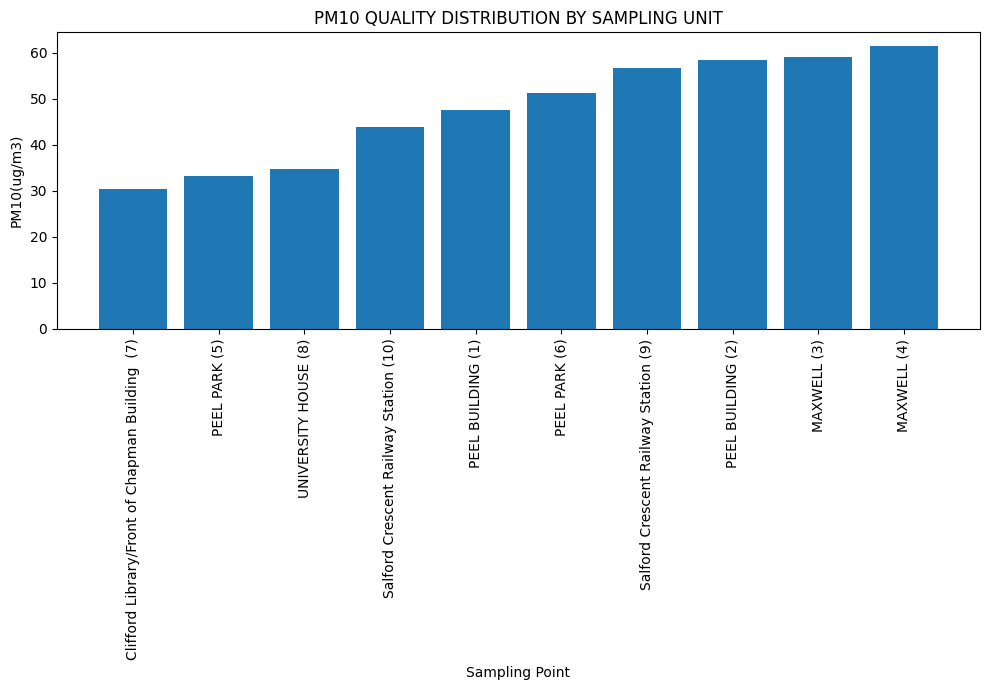

In [94]:
plt.figure(figsize=(10, 7))
plt.bar(df_group.sort_values(by="PM10(ug/m3)")["labels"], df_group.sort_values(by="PM10(ug/m3)")["PM10(ug/m3)"])
plt.xlabel("Sampling Point")
plt.ylabel("PM10(ug/m3)")
plt.title("PM10 QUALITY DISTRIBUTION BY SAMPLING UNIT")
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig("PM10 AIRING 2000.png")
plt.show()

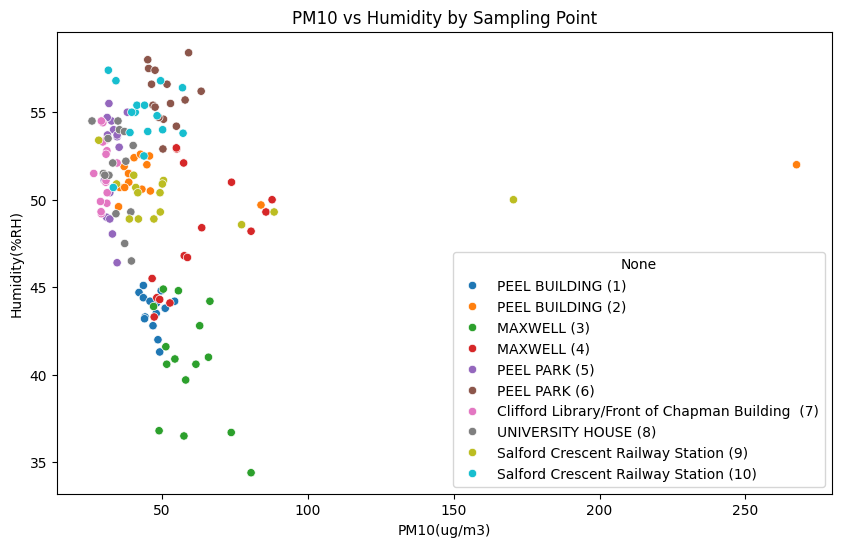

In [95]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="PM10(ug/m3)",
    y="Humidity(%RH)",
    hue=df_labels
)

plt.title("PM10 vs Humidity by Sampling Point")
plt.savefig("PM10 & Humidity.png")
plt.show()

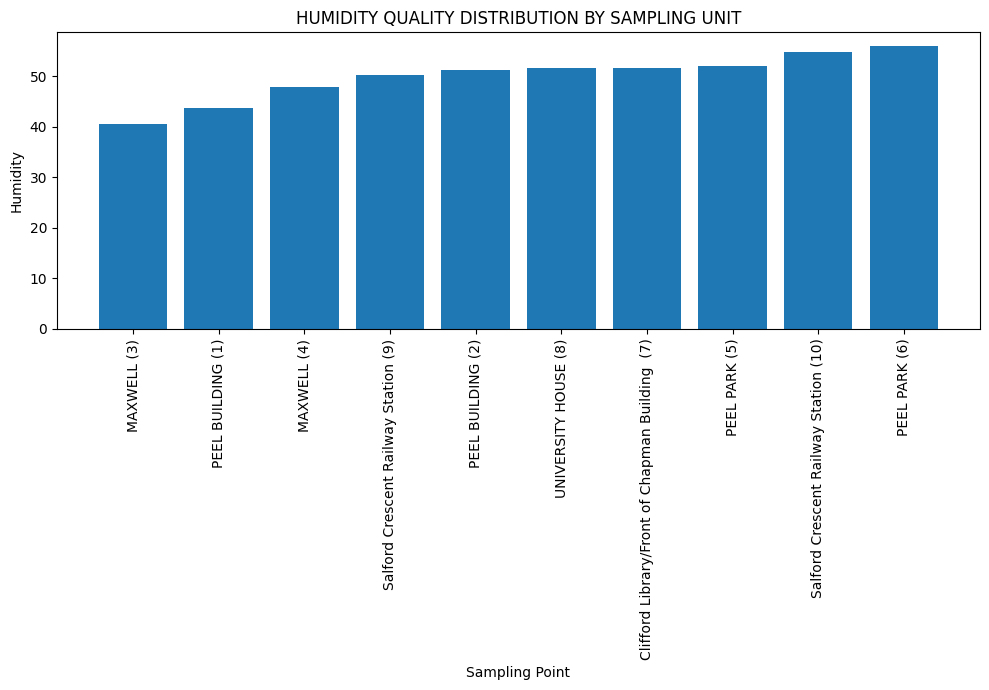

In [96]:
plt.figure(figsize=(10, 7))
plt.bar(df_group.sort_values(by="Humidity(%RH)")["labels"], df_group.sort_values(by="Humidity(%RH)")["Humidity(%RH)"])
plt.xlabel("Sampling Point")
plt.ylabel("Humidity")
plt.title("HUMIDITY QUALITY DISTRIBUTION BY SAMPLING UNIT")
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig("Humidity AIRING 2000.png")
plt.show()

In [98]:
col = ['PM2.5(ug/m3)', 'PM10(ug/m3)',
       'Humidity(%RH)']

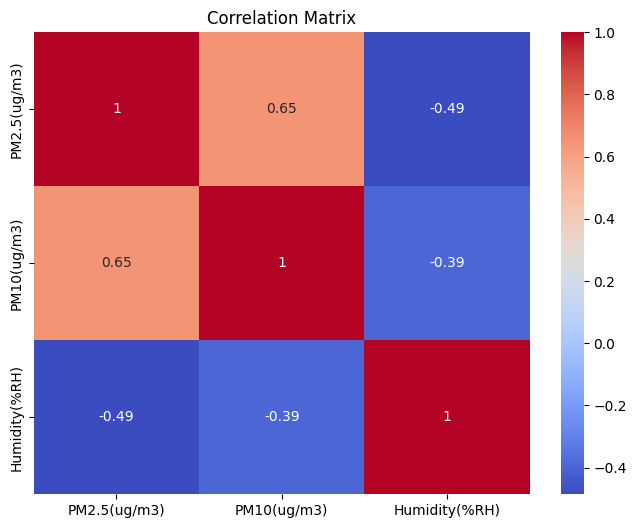

In [99]:
corr = df_group[col].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.savefig("Correlation Matrix (Airing 2000).png")
plt.show()

In [100]:
#Convert datapoint to lat and lon

from pyproj import Transformer


transformer = Transformer.from_crs("EPSG:27700", "EPSG:4326")
coordinates = {
    1: [81994, 98686],
    2: [82000, 98731],
    5: [82146, 98759],
    7: [82174, 98882],
    9: [81838, 98785]
}


df_group["Latitude"] = None
df_group["Longitude"] = None

for samp, (east, north) in coordinates.items():
    full_east = east + 300000
    full_north = north + 300000
    
    lat, lon = transformer.transform(full_east, full_north)
    
    # Update the specific row in df_group where the SAMPLING POINT matches
    df_group.loc[df_group["SAMPLING POINT"] == samp, ["Latitude", "Longitude"]] = [lat, lon]
    
    print(f"Point {samp} converted: {lat:.5f}, {lon:.5f}")

# Display the updated dataframe
df_group.head()

Point 1 converted: 53.48458, -2.27281
Point 2 converted: 53.48498, -2.27272
Point 5 converted: 53.48524, -2.27053
Point 7 converted: 53.48635, -2.27011
Point 9 converted: 53.48546, -2.27517


,AREA,SAMPLING POINT,PM2.5(ug/m3),PM10(ug/m3),Humidity(%RH),labels,Latitude,Longitude
0,Salford Crescent Railway Station,9,10.328352,56.696923,50.204835,Salford Crescent Railway Station (9),53.485463,-2.275169
1,Clifford Library/Front of Chapman Building,7,11.058681,30.320440,51.687692,Clifford Library/Front of Chapman Building (7),53.486347,-2.270111
2,Salford Crescent Railway Station,10,11.828571,43.767253,54.782637,Salford Crescent Railway Station (10),None,None
3,PEEL PARK,5,12.233846,33.165934,52.102857,PEEL PARK (5),53.48524,-2.270526
4,UNIVERSITY HOUSE,8,12.653333,34.633333,51.640000,UNIVERSITY HOUSE (8),None,None


In [101]:
coord = {
    3: ["53˚29’06", "2˚16’04"],
    4: ["53˚29’12", "2˚16’26"],
    6: ["53˚29’17", "2˚16’14"],
    8: ["53˚29’20", "2˚16’24"],
    10: ["53˚29’11", "2˚16’32"]
}

def dms_to_dd(dms_str, direction='N'):
    dms_str = dms_str.replace("˚", " ").replace("’", " ").replace('"', " ")
    parts = dms_str.split()

    d = int(parts[0])
    m = int(parts[1])
    s = int(parts[2])

    dd = d + m / 60 + s / 3600

    if direction in ['W', 'S']:
        dd *= -1

    return dd

In [102]:
for sam, coords in coord.items():
    lat = coords[0]
    lon = coords[1]
    lati = dms_to_dd(lat)
    loni = dms_to_dd(lon, 'W')
    df_group.loc[df_group["SAMPLING POINT"] == sam, ["Latitude", "Longitude"]] = lati, loni

In [103]:
df_group

,AREA,SAMPLING POINT,PM2.5(ug/m3),PM10(ug/m3),Humidity(%RH),labels,Latitude,Longitude
0,Salford Crescent Railway Station,9,10.328352,56.696923,50.204835,Salford Crescent Railway Station (9),53.485463,-2.275169
1,Clifford Library/Front of Chapman Building,7,11.058681,30.320440,51.687692,Clifford Library/Front of Chapman Building (7),53.486347,-2.270111
2,Salford Crescent Railway Station,10,11.828571,43.767253,54.782637,Salford Crescent Railway Station (10),53.486389,-2.275556
3,PEEL PARK,5,12.233846,33.165934,52.102857,PEEL PARK (5),53.48524,-2.270526
4,UNIVERSITY HOUSE,8,12.653333,34.633333,51.640000,UNIVERSITY HOUSE (8),53.488889,-2.273333
5,PEEL BUILDING,2,14.840000,58.400000,51.280000,PEEL BUILDING (2),53.484984,-2.272725
6,PEEL BUILDING,1,15.944615,47.451648,43.680000,PEEL BUILDING (1),53.484579,-2.272813
7,PEEL PARK,6,17.809231,51.340879,55.932747,PEEL PARK (6),53.488056,-2.270556
8,MAXWELL,3,20.285165,59.167582,40.626154,MAXWELL (3),53.485,-2.267778
9,MAXWELL,4,22.973187,61.353333,47.997582,MAXWELL (4),53.486667,-2.273889


C:\Users\USER\AppData\Local\Temp\ipykernel_1180\1772967595.py:1: DeprecationWarning:

*scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/



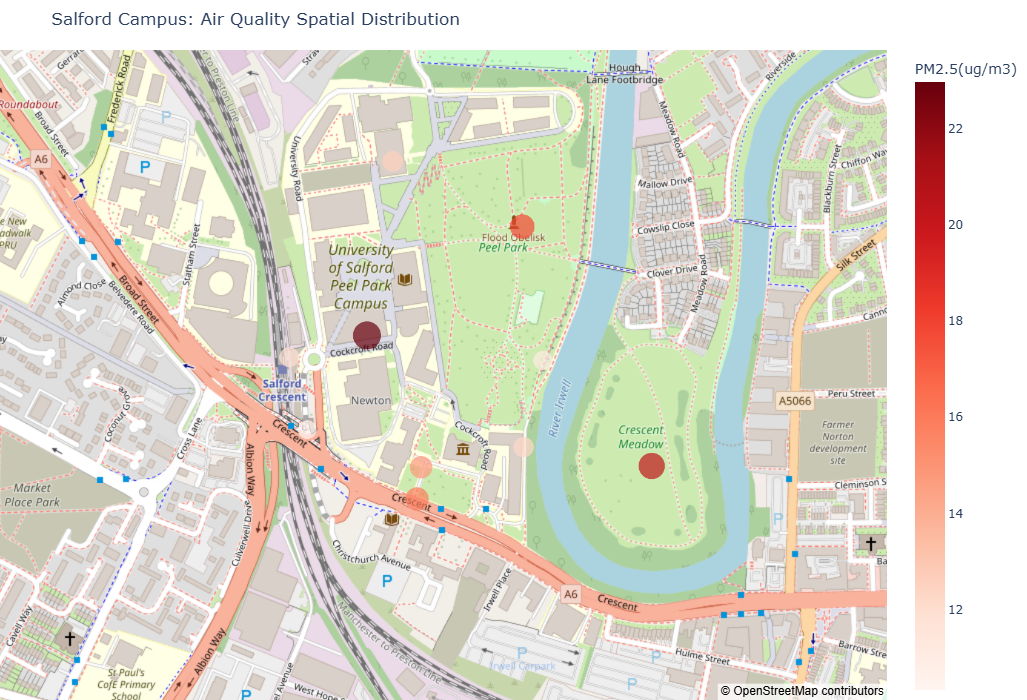

In [104]:
fig = px.scatter_mapbox(
    df_group,
    lat='Latitude',
    lon='Longitude',
    hover_name='AREA',
    color='PM2.5(ug/m3)', # Color points by pollution level
    size='PM2.5(ug/m3)',  # Larger dots for more pollution
    color_continuous_scale=px.colors.sequential.Reds,
    hover_data={
        'SAMPLING POINT': True,
        'PM2.5(ug/m3)': ':.2f',
        'PM10(ug/m3)': ':.2f',
        'Humidity(%RH)': ':.1f',
        'Latitude': False,
        'Longitude': False
    },
    zoom=15, # Focus on Salford Campus
    title='Salford Campus: Air Quality Spatial Distribution'
)

# Update layout to use OpenStreetMap
fig.update_layout(
    mapbox_style="open-street-map",
    margin={"r":0,"t":50,"l":0,"b":0},
    height=700
)

fig.show()
fig.write_image("Campus_Pollution_Map.png")

# EXPLORING TEMTOP M2000 SERIES READINGS

In [45]:
df2 = pd.read_excel(r"C:\Users\USER\Downloads\AIr Quality Data - RDD 2026.xlsx", sheet_name="Sheet2")

In [46]:
df2

,DATE,TIME,AREA,SAMPLING POINT,PM2.5(ug/m3),PM10(ug/m3),CO2(ppm),TEMPERATURE (Celcius),HUMIDITY(%)
0,2026-03-04,10:39:00,PEEL BUILDING,1,4.7,8.1,467.0,19.1,49.6
1,2026-03-04,10:40:00,PEEL BUILDING,1,3.7,6.4,469.0,19.6,49.0
2,2026-03-04,10:41:00,PEEL BUILDING,1,3.7,6.5,464.0,19.9,48.4
3,2026-03-04,10:42:00,PEEL BUILDING,1,3.0,5.0,457.0,19.7,48.8
4,2026-03-04,10:43:00,PEEL BUILDING,1,4.0,6.5,444.0,19.4,48.2
...,...,...,...,...,...,...,...,...,...
145,2026-03-04,12:41:00,Salford Crescent Railway Station,10,5.0,8.0,439.0,20.6,49.7
146,2026-03-04,12:42:00,Salford Crescent Railway Station,10,3.3,5.6,448.0,20.8,49.4
147,2026-03-04,12:43:00,Salford Crescent Railway Station,10,2.8,4.5,445.0,21.0,49.5
148,2026-03-04,12:44:00,Salford Crescent Railway Station,10,2.5,3.9,450.0,21.5,49.4


In [47]:
df2.columns = df2.columns.str.strip()

In [48]:
#Grouping data based on area and sampling point
cols = ["PM2.5(ug/m3)", "PM10(ug/m3)", "CO2(ppm)", "TEMPERATURE (Celcius)", "HUMIDITY(%)"]

df2_group = df2.groupby(["AREA", "SAMPLING POINT"])[cols].mean().sort_values(by=cols ).reset_index()

In [49]:
df2_labels = df2["AREA"] + " (" + df2["SAMPLING POINT"].astype(str) + ")"

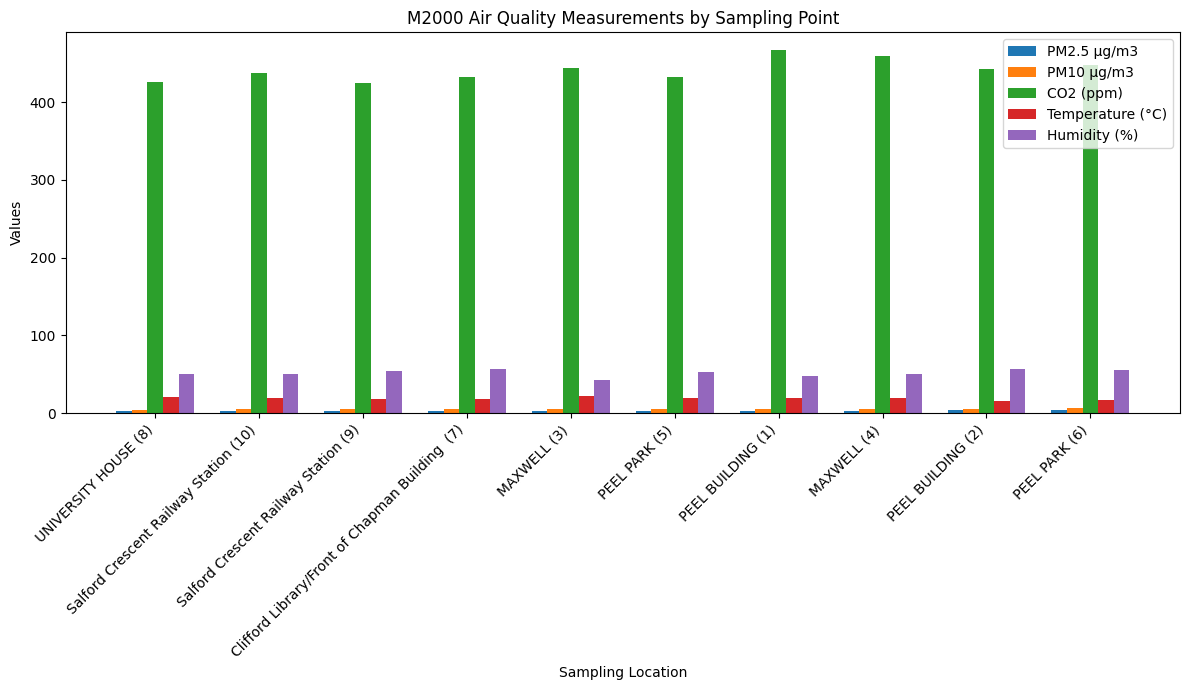

In [50]:
x = np.arange(len(df2_group))
width = 0.15  # reduce width since we have 5 bars

plt.figure(figsize=(12,7))

plt.bar(x - 2*width, df2_group["PM2.5(ug/m3)"], width, label="PM2.5 µg/m3")
plt.bar(x - width, df2_group["PM10(ug/m3)"], width, label="PM10 µg/m3")
plt.bar(x, df2_group["CO2(ppm)"], width, label="CO2 (ppm)")
plt.bar(x + width, df2_group["TEMPERATURE (Celcius)"], width, label="Temperature (°C)")
plt.bar(x + 2*width, df2_group["HUMIDITY(%)"], width, label="Humidity (%)")

# Labels
labels = df2_group["AREA"] + " (" + df2_group["SAMPLING POINT"].astype(str) + ")"
plt.xticks(x, labels, rotation=45, ha="right")

plt.xlabel("Sampling Location")
plt.ylabel("Values")
plt.title("M2000 Air Quality Measurements by Sampling Point")

plt.legend()
plt.tight_layout()
plt.savefig("M2000 all col.png")
plt.show()

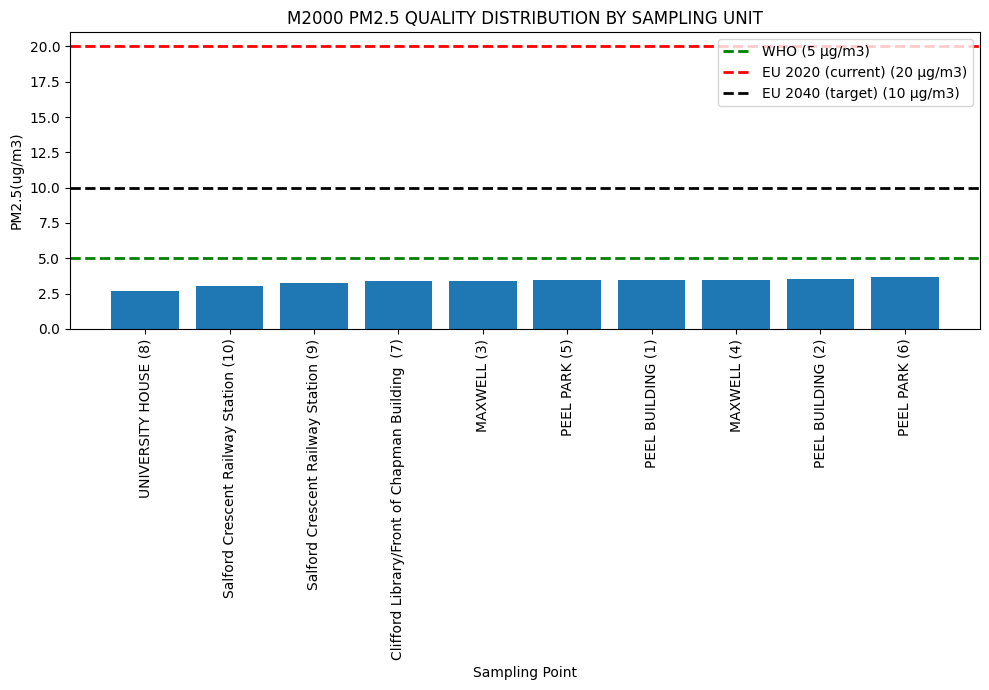

In [51]:
plt.figure(figsize=(10, 7))
plt.bar(labels, df2_group["PM2.5(ug/m3)"])

#Organisational Threshold
plt.axhline(y=5, color='green', linestyle='--', linewidth=2, label='WHO (5 µg/m3)')
plt.axhline(y=20, color='red', linestyle='--', linewidth=2, label='EU 2020 (current) (20 µg/m3)')
plt.axhline(y=10, color='black', linestyle='--', linewidth=2, label='EU 2040 (target) (10 µg/m3)')

plt.xlabel("Sampling Point")
plt.ylabel("PM2.5(ug/m3)")
plt.title("M2000 PM2.5 QUALITY DISTRIBUTION BY SAMPLING UNIT")
plt.legend()
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig("M2000 PM2.5 AIRING 2000.png")
plt.show()

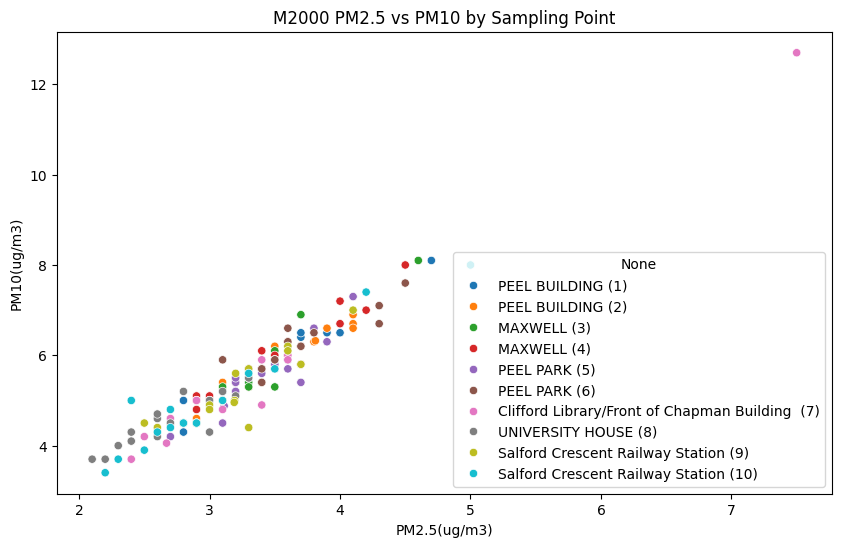

In [52]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df2,
    x="PM2.5(ug/m3)",
    y="PM10(ug/m3)",
    hue=df2_labels
)

plt.title("M2000 PM2.5 vs PM10 by Sampling Point")
plt.savefig("M2000 PM2.5 & PM10.png")
plt.show()

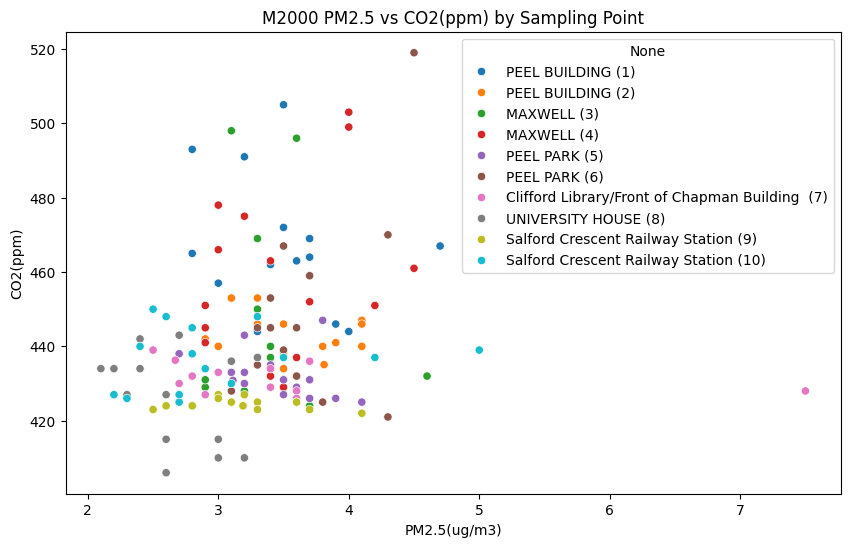

In [53]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df2,
    x="PM2.5(ug/m3)",
    y="CO2(ppm)",
    hue=df2_labels
)

plt.title("M2000 PM2.5 vs CO2(ppm) by Sampling Point")
plt.savefig("M2000 PM2.5 & CO2(ppm).png")
plt.show()

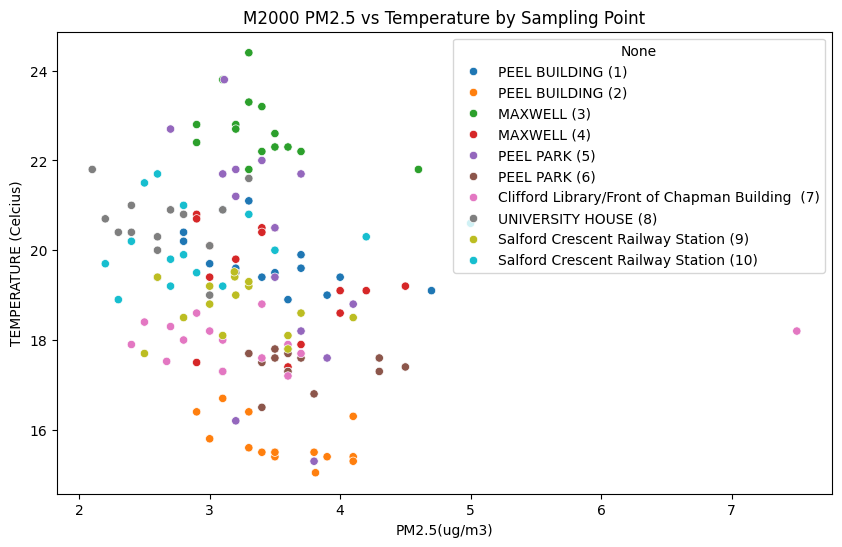

In [54]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df2,
    x="PM2.5(ug/m3)",
    y="TEMPERATURE (Celcius)",
    hue=df2_labels
)

plt.title("M2000 PM2.5 vs Temperature by Sampling Point")
plt.savefig("M2000 PM2.5 & Temperature.png")
plt.show()

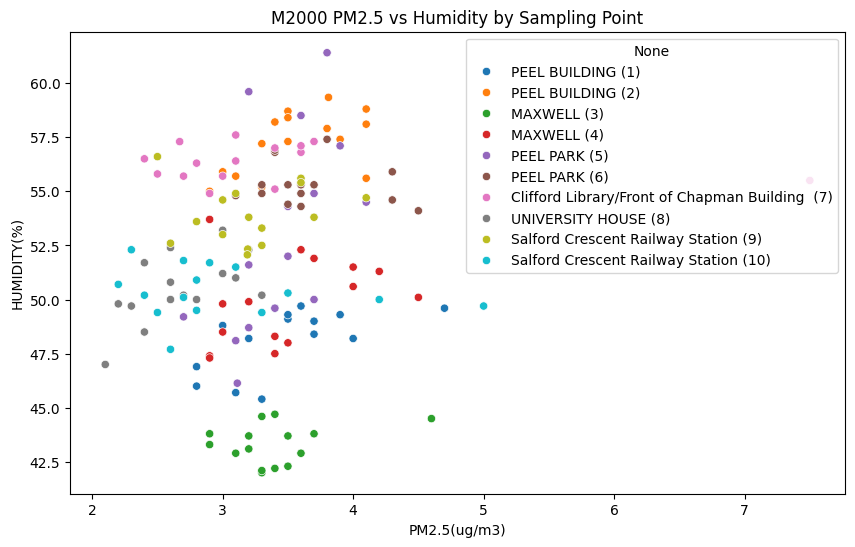

In [55]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df2,
    x="PM2.5(ug/m3)",
    y="HUMIDITY(%)",
    hue=df2_labels
)

plt.title("M2000 PM2.5 vs Humidity by Sampling Point")
plt.savefig("M2000 PM2.5 & Humidity.png")
plt.show()

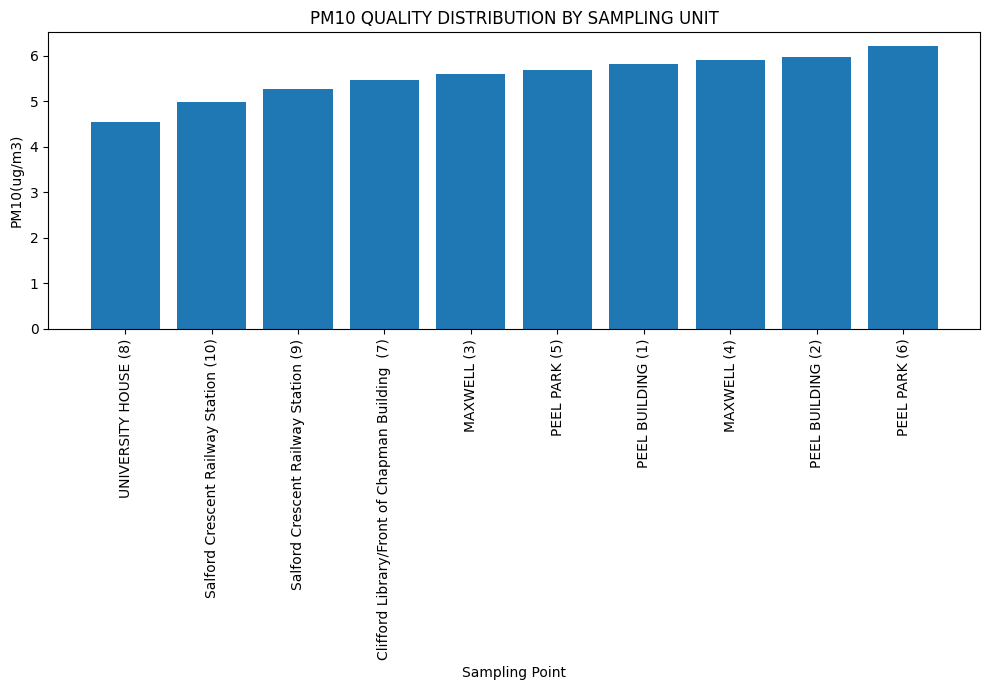

In [56]:
plt.figure(figsize=(10, 7))
plt.bar(labels, df2_group.sort_values(by="PM10(ug/m3)")["PM10(ug/m3)"])
plt.xlabel("Sampling Point")
plt.ylabel("PM10(ug/m3)")
plt.title("PM10 QUALITY DISTRIBUTION BY SAMPLING UNIT")
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig("M2000 PM10 AIRING 2000.png")
plt.show()

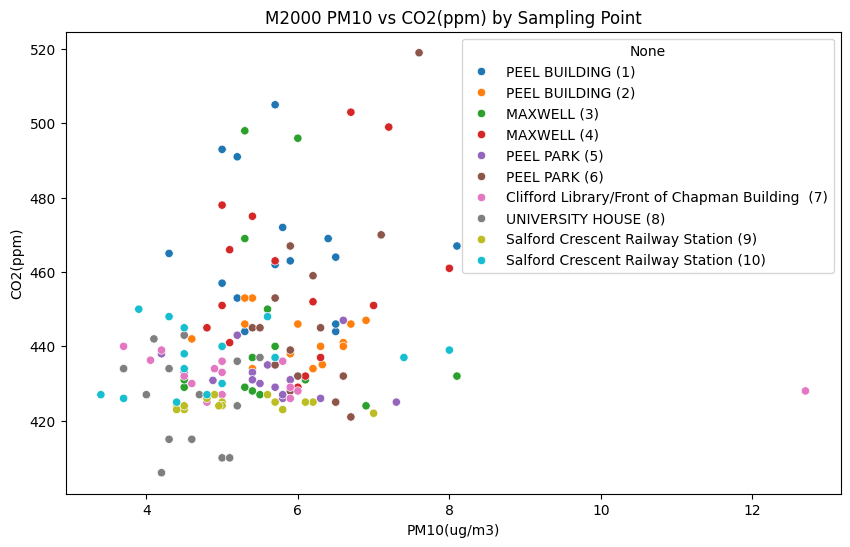

In [57]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df2,
    x="PM10(ug/m3)",
    y="CO2(ppm)",
    hue=df2_labels
)

plt.title("M2000 PM10 vs CO2(ppm) by Sampling Point")
plt.savefig("M2000 PM10 & CO2(ppm).png")
plt.show()

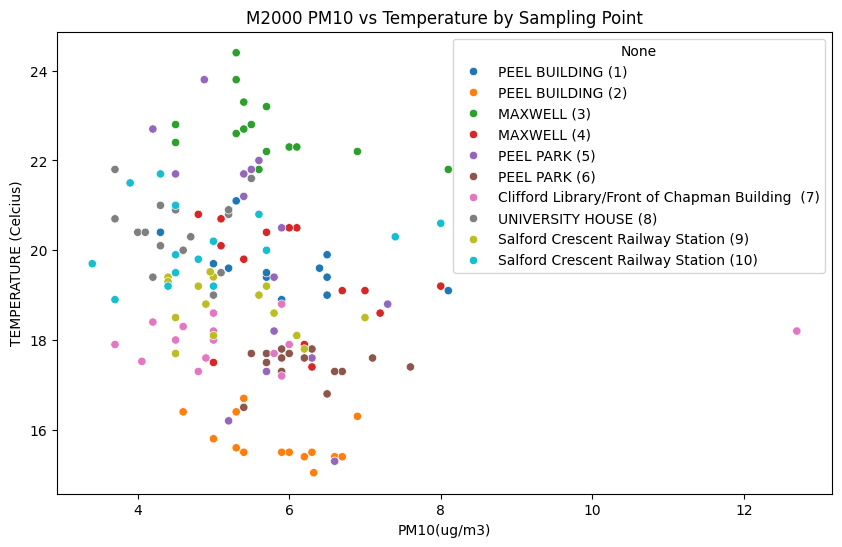

In [58]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df2,
    x="PM10(ug/m3)",
    y="TEMPERATURE (Celcius)",
    hue=df2_labels
)

plt.title("M2000 PM10 vs Temperature by Sampling Point")
plt.savefig("M2000 PM10 & Temperature.png")
plt.show()

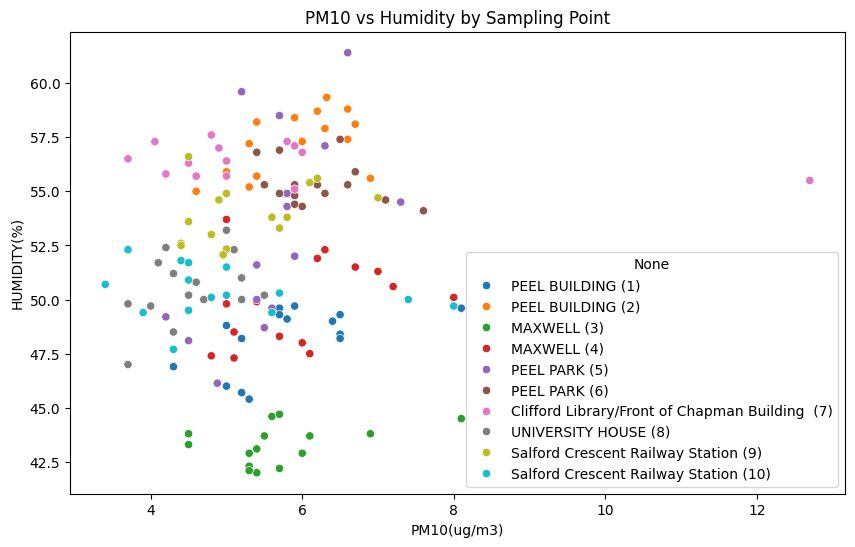

In [59]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df2,
    x="PM10(ug/m3)",
    y="HUMIDITY(%)",
    hue=df2_labels
)

plt.title("PM10 vs Humidity by Sampling Point")
plt.savefig("M2000 PM10 & Humidity.png")
plt.show()

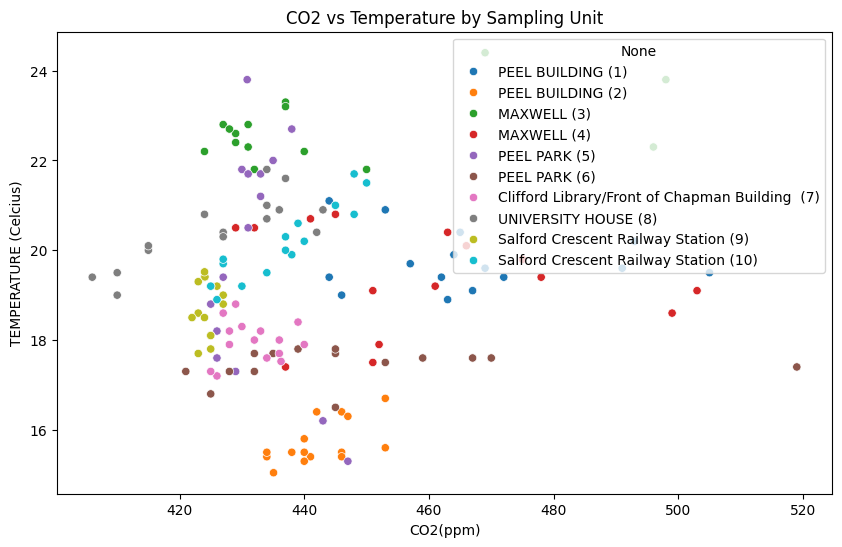

In [60]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df2,
    x="CO2(ppm)",
    y="TEMPERATURE (Celcius)",
    hue=df2_labels
)

plt.title("CO2 vs Temperature by Sampling Unit")
plt.savefig("M2000 CO2 & Temperature.png")
plt.show()

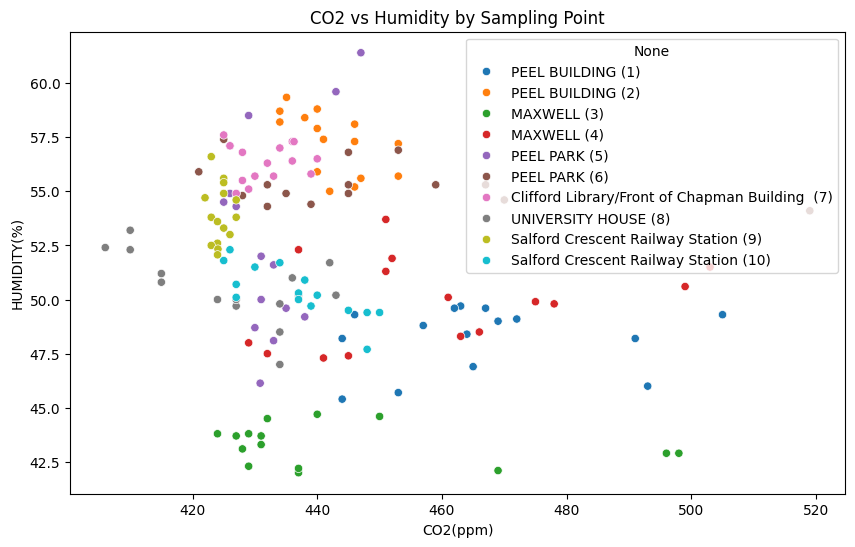

In [61]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df2,
    x="CO2(ppm)",
    y="HUMIDITY(%)",
    hue=df2_labels
)

plt.title("CO2 vs Humidity by Sampling Point")
plt.savefig("M2000 CO2 & Humidity.png")
plt.show()

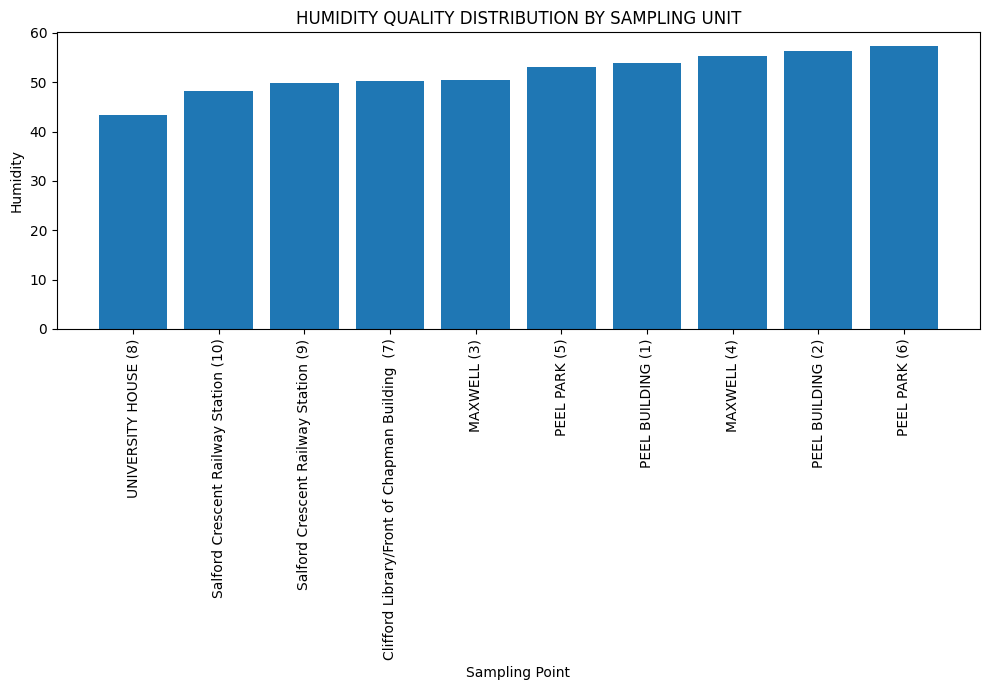

In [62]:
plt.figure(figsize=(10, 7))
plt.bar(labels, df2_group.sort_values(by="HUMIDITY(%)")["HUMIDITY(%)"])
plt.xlabel("Sampling Point")
plt.ylabel("Humidity")
plt.title("HUMIDITY QUALITY DISTRIBUTION BY SAMPLING UNIT")
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig("M2000 Humidity.png")
plt.show()

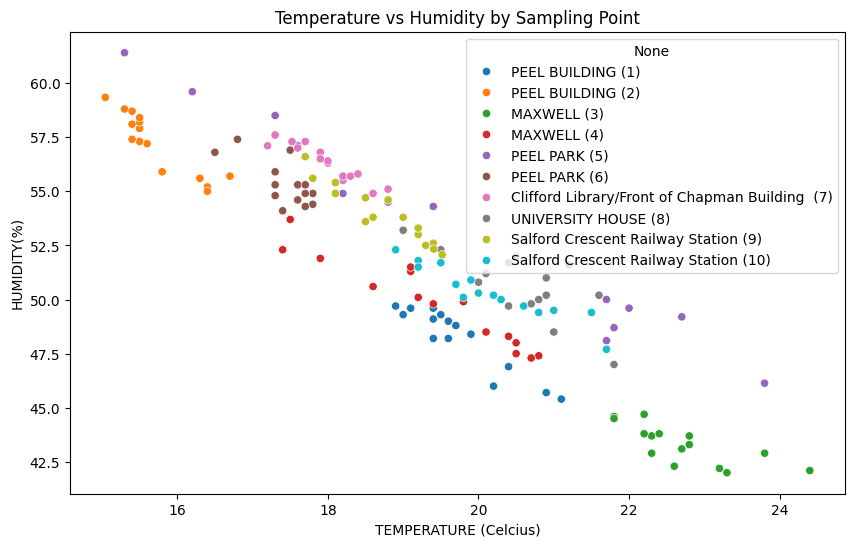

In [63]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df2,
    x="TEMPERATURE (Celcius)",
    y="HUMIDITY(%)",
    hue=df2_labels
)

plt.title("Temperature vs Humidity by Sampling Point")
plt.savefig("M2000 Temperature & Humidity.png")
plt.show()

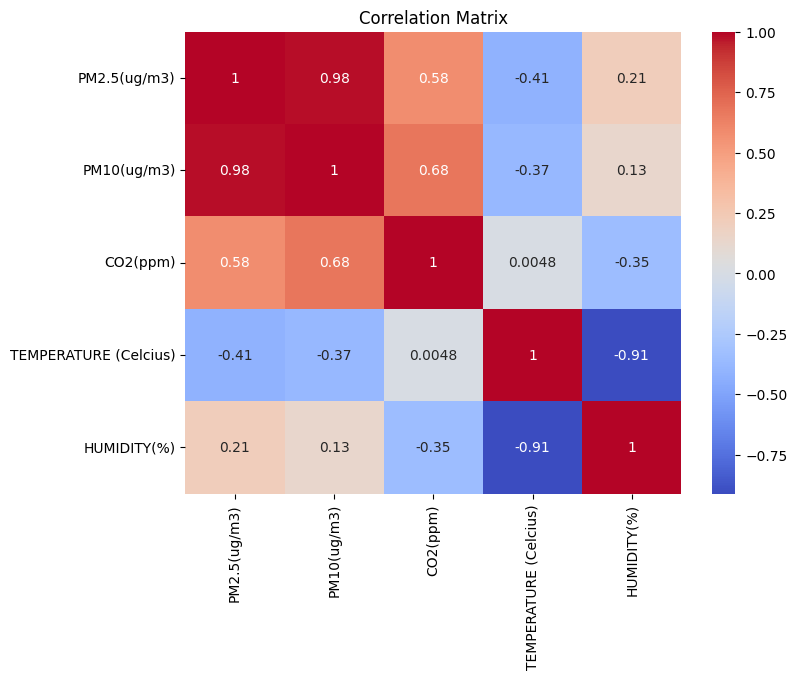

In [64]:
corr = df2_group[cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.savefig("Correlation Matrix (M2000).png")
plt.show()